# phase 1:set aggregator Prototype

**goal:** Validate the permutation invariant architecture. We are mapping variable-length catalogs of mixed multi messenger observations directly to a point estimate of the spectral EOS parameters `θ = [γ₀, γ₁, γ₂, γ₃]`.

**note:** To iterate quickly, this notebook uses a dummy linear forward model to bypass the computational overhead of integrating the actual TOV equations. The dataset generators, custom collate functions, aggregator architecture, and training loop are the actual production versions and will port directly to Phase 2.

---

## 0. Imports & Config

Global imports and environment setup.

In [ ]:
#  Standard library
import os
import random

#  PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

#  Plotting
import matplotlib.pyplot as plt

#  Google Drive mount
from google.colab import drive
drive.mount('/content/drive')

#  Project root (edit this if you move the project folder)
PROJECT_ROOT = '/content/drive/MyDrive/ns_eos_project'

print('Imports OK.')
print(f'Project root: {PROJECT_ROOT}')

Mounted at /content/drive
Imports OK.
Project root: /content/drive/MyDrive/ns_eos_project


---
## Section 1: Folder Structure, Paths & Device

In [ ]:
# ── Create project folder tree (safe to re-run; exist_ok=True) ────────────────
folders = [
    'data/raw',        # raw EOS samples and synthetic observation arrays
    'data/processed',  # cleaned / normalised versions for training
    'models',          # architecture definitions and saved configs
    'figures',         # all plots and visualisations
    'checkpoints',     # saved model weights (.pt files)
    'notebooks',       # experimental / scratch notebooks
]

for folder in folders:
    path = os.path.join(PROJECT_ROOT, folder)
    os.makedirs(path, exist_ok=True)
    print(f'  ✓ {path}')

# ── Path constants (import these at the top of every future notebook) ──────────
DATA_RAW       = os.path.join(PROJECT_ROOT, 'data/raw')
DATA_PROCESSED = os.path.join(PROJECT_ROOT, 'data/processed')
MODELS         = os.path.join(PROJECT_ROOT, 'models')
FIGURES        = os.path.join(PROJECT_ROOT, 'figures')
CHECKPOINTS    = os.path.join(PROJECT_ROOT, 'checkpoints')

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\nDevice: {device}')

# ── Utility: move a batch dict to the target device ───────────────────────────
def move_to_device(batch: dict, device: torch.device) -> dict:
    """Move all tensor values in a batch dict onto `device`."""
    return {
        k: v.to(device) if torch.is_tensor(v) else v
        for k, v in batch.items()
    }

print('\nProject structure ready.')

  ✓ /content/drive/MyDrive/ns_eos_project/data/raw
  ✓ /content/drive/MyDrive/ns_eos_project/data/processed
  ✓ /content/drive/MyDrive/ns_eos_project/models
  ✓ /content/drive/MyDrive/ns_eos_project/figures
  ✓ /content/drive/MyDrive/ns_eos_project/checkpoints
  ✓ /content/drive/MyDrive/ns_eos_project/notebooks

Device: cuda

Project structure ready.


---
## Section 2: EOS Prior & Target Normalisation

The EOS is parameterised by four spectral coefficients
`θ = [γ₀, γ₁, γ₂, γ₃]` following Carney et al. (2018).

| Parameter | Physical role | Prior range |
|-----------|---------------|-------------|
| γ₀ | Overall EOS stiffness | [0.2, 2.0] |
| γ₁ | First-order density dependence | [−1.6, 1.7] |
| γ₂ | Higher-order corrections | [−0.6, 0.6] |
| γ₃ | Fine structure | [−0.02, 0.02] |

It normalises the targets before computing the MSE loss so that all four
parameters contribute equally — without normalisation the loss would be
dominated by γ₀ (range ~1.8) and the network would barely learn γ₃ (range 0.04).

In [ ]:
# ── Prior bounds (used in generate_toy_sample) ────────────────────────────────
PRIOR_BOUNDS = {
    'gamma0': (0.2,   2.0),
    'gamma1': (-1.6,  1.7),
    'gamma2': (-0.6,  0.6),
    'gamma3': (-0.02, 0.02),
}

# ── Normalisation constants for the EOS parameter vector ─────────────────────
# mean and std are set to approximately centre and scale each parameter
# to unit normal range given the prior bounds above.
theta_mean = torch.tensor([1.10,  0.05, 0.00, 0.000], device=device)
theta_std  = torch.tensor([0.52,  0.96, 0.35, 0.012], device=device)

def normalize_theta(theta: torch.Tensor) -> torch.Tensor:
    """Map raw EOS parameters to approximately N(0,1) per dimension."""
    return (theta - theta_mean) / theta_std

def denormalize_theta(theta_norm: torch.Tensor) -> torch.Tensor:
    """Invert normalize_theta — convert normalised predictions back to physical units."""
    return theta_norm * theta_std + theta_mean

print('EOS prior and normalisation helpers defined.')
print(f'  theta_mean = {theta_mean.tolist()}')
print(f'  theta_std  = {theta_std.tolist()}')

EOS prior and normalisation helpers defined.
  theta_mean = [1.100000023841858, 0.05000000074505806, 0.0, 0.0]
  theta_std  = [0.5199999809265137, 0.9599999785423279, 0.3499999940395355, 0.012000000104308128]


---
## Section 3 — Toy Forward Model (Fake Observation Generation)

this is a simple linear map `θ → observations` that stands in for the
real TOV solver + NICER / GW pipeline.  It keeps all the structure that
matters for testing the architecture:
- Three heterogeneous messenger types with different dimensionalities
- Variable-size catalogs per EOS (not every EOS has every messenger type)
- Realistic relative noise levels

**Phase 2** will replace `forward_model` with the CompactObject TOV solver and
calibrated O4 noise injections.  Everything else in this notebook will stay.

### Observable -> parameter mapping
```
λ̃  = 200 + 80·γ₀ + 70·γ₁ + 30·γ₂ + 500·γ₃   (GW tidal deformability)
Mc  = 1.2 + 0.15·γ₀ − 0.12·γ₁ + 0.08·γ₂ − 2.0·γ₃   (chirp mass)
M   = 1.4 + 0.15·γ₀ + 0.18·γ₁ − 0.10·γ₂ + 3.0·γ₃   (NICER mass)
R   = 11.0 + 0.8·γ₀ − 0.7·γ₁ + 0.9·γ₂ + 10.0·γ₃   (NICER radius)
Mp  = 1.8 + 0.15·γ₀ + 0.12·γ₁ + 0.10·γ₂ − 4.0·γ₃   (pulsar mass)
```
All four parameters influence every observable, so the network has a
reason to recover all four dimensions.

In [ ]:
def forward_model(theta_eos: list) -> list:
    """
    Toy forward model: EOS parameters → multi-messenger observations.

    Each observation independently samples a realistic measurement uncertainty
    (sigma) and then draws its measured value from N(true_value, sigma).
    This means sigma is honest: it reflects how noisy each measurement actually is,
    and the model can use it as an input to weight observations accordingly.

    Sigma ranges are loosely motivated by current detector capabilities:
      GW   - lambda_tilde: ~30-150 (LIGO O3-era posterior widths)
           - chirp_mass:   ~0.001-0.008 M_sun (very precisely measured)
      NICER - mass:   ~0.04-0.15 M_sun
            - radius: ~0.3-1.0 km
      Pulsar mass: ~0.005-0.025 M_sun
    """
    g0, g1, g2, g3 = theta_eos

    # Noiseless observable values from EOS params (linear toy model)
    lambda_tilde_true = 200  + 80*g0 + 70*g1 + 30*g2 + 500*g3
    chirp_mass_true   = 1.2  + 0.15*g0 - 0.12*g1 + 0.08*g2 - 2.0*g3
    mass_true         = 1.4  + 0.15*g0 + 0.18*g1 - 0.10*g2 + 3.0*g3
    radius_true       = 11.0 + 0.8*g0  - 0.7*g1  + 0.9*g2  + 10.0*g3
    pulsar_mass_true  = 1.8  + 0.15*g0 + 0.12*g1 + 0.10*g2 - 4.0*g3

    observations = []

    # GW events: present in ~80% of catalogs, 1-3 events each
    if random.random() < 0.8:
        for _ in range(random.randint(1, 3)):
            sigma_lambda = random.uniform(30.0, 150.0)
            sigma_mc     = random.uniform(0.001, 0.008)
            observations.append({
                'type':  'gw',
                'x':     [lambda_tilde_true + random.gauss(0, sigma_lambda),
                          chirp_mass_true   + random.gauss(0, sigma_mc)],
                'sigma': [sigma_lambda, sigma_mc],
            })

    # NICER X-ray: present in ~70% of catalogs, 1-2 sources each
    if random.random() < 0.7:
        for _ in range(random.randint(1, 2)):
            sigma_mass   = random.uniform(0.04, 0.15)
            sigma_radius = random.uniform(0.3, 1.0)
            observations.append({
                'type':  'nicer',
                'x':     [mass_true   + random.gauss(0, sigma_mass),
                          radius_true + random.gauss(0, sigma_radius)],
                'sigma': [sigma_mass, sigma_radius],
            })

    # Pulsar timing mass: present in ~60% of catalogs, one measurement
    if random.random() < 0.6:
        sigma_pm = random.uniform(0.005, 0.025)
        observations.append({
            'type':  'pulsar',
            'x':     [pulsar_mass_true + random.gauss(0, sigma_pm)],
            'sigma': [sigma_pm],
        })

    # Guarantee at least one observation per catalog
    if len(observations) == 0:
        sigma_lambda = random.uniform(30.0, 150.0)
        sigma_mc     = random.uniform(0.001, 0.008)
        observations.append({
            'type':  'gw',
            'x':     [lambda_tilde_true + random.gauss(0, sigma_lambda),
                      chirp_mass_true   + random.gauss(0, sigma_mc)],
            'sigma': [sigma_lambda, sigma_mc],
        })

    return observations


def generate_toy_sample() -> dict:
    """
    Draw one EOS from the prior and run the forward model to get a catalog.

    Returns
    -------
    dict with keys:
      'theta_eos' : list[float]  — the true EOS parameter vector
      'catalog'   : list[dict]   — the corresponding observations
    """
    theta_eos = [
        random.uniform(*PRIOR_BOUNDS['gamma0']),
        random.uniform(*PRIOR_BOUNDS['gamma1']),
        random.uniform(*PRIOR_BOUNDS['gamma2']),
        random.uniform(*PRIOR_BOUNDS['gamma3']),
    ]
    catalog = forward_model(theta_eos)
    return {'theta_eos': theta_eos, 'catalog': catalog}


# Quick sanity check
sample = generate_toy_sample()
print('Example generated sample:')
print(f"  theta_eos : {[f'{v:.4f}' for v in sample['theta_eos']]}")
print(f"  catalog   : {len(sample['catalog'])} observations")
for obs in sample['catalog']:
    print(f"    [{obs['type']:>6}]  x={[f'{v:.3f}' for v in obs['x']]}  sigma={[f'{v:.4f}' for v in obs['sigma']]}")

---
## Section 4 — Dataset & Collate Function

### Data structure

Each training example is a **(theta_eos, catalog)** pair:

```python
{
    'theta_eos': [γ₀, γ₁, γ₂, γ₃],      # the ground-truth EOS we want to recover
    'catalog': [
        {'type': 'gw',     'x': [λ̃, Mc],  'sigma': [σ_λ, σ_Mc]},
        {'type': 'nicer',  'x': [M, R],   'sigma': [σ_M, σ_R]},
        {'type': 'pulsar', 'x': [Mp],     'sigma': [σ_Mp]},
        # ...any number and mix of messenger types
    ]
}
```

The catalog is an **unordered set** so the EOS posterior must not depend on
the order observations are listed.  `collate_fn` groups observations by
messenger type and records which catalog each observation belongs to via
`catalog_idx`.  This allows `scatter_add` mean pooling in the model's
forward pass without any padding.

In [ ]:
class EOSCatalogDataset(Dataset):
    """
    Wraps a list of (theta_eos, catalog) dicts and converts them to tensors.

    Each item returned by __getitem__ is:
        {
            'theta'  : FloatTensor[4]          — EOS parameter vector
            'catalog': list of observation dicts with 'type', 'x', 'sigma'
                       where 'x' and 'sigma' are FloatTensors.
        }
    """
    def __init__(self, samples: list):
        self.samples = samples

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, idx: int) -> dict:
        sample = self.samples[idx]

        theta = torch.tensor(sample['theta_eos'], dtype=torch.float32)

        catalog = [
            {
                'type':  obs['type'].lower(),
                'x':     torch.tensor(obs['x'],     dtype=torch.float32),
                'sigma': torch.tensor(obs['sigma'], dtype=torch.float32),
            }
            for obs in sample['catalog']
        ]

        return {'theta': theta, 'catalog': catalog}


def collate_fn(batch: list) -> dict:
    """
    Custom collate that handles variable-size heterogeneous catalogs.

    Instead of padding catalogs to a fixed length, we:
      1. Stack all theta vectors into a (B, 4) tensor.
      2. Group observations by messenger type across the batch.
      3. For each type, stack x and sigma into tensors, and record which
         catalog in the batch each observation belongs to via `catalog_idx`.

    The model uses `catalog_idx` with `scatter_add` to pool observations
    back to their parent catalog.
    """
    #  Stack EOS ground-truth vectors
    thetas = torch.stack([item['theta'] for item in batch], dim=0)  # (B, 4)
    num_catalogs = len(batch)

    #  Initialise per-type accumulators
    # 'dim' is the observation dimensionality, needed to create empty tensors
    # when a messenger type is absent from the whole batch.
    grouped = {
        'gw':     {'x': [], 'sigma': [], 'catalog_idx': [], 'dim': 2},
        'nicer':  {'x': [], 'sigma': [], 'catalog_idx': [], 'dim': 2},
        'pulsar': {'x': [], 'sigma': [], 'catalog_idx': [], 'dim': 1},
    }

    for catalog_idx, item in enumerate(batch):
        for obs in item['catalog']:
            t = obs['type']
            grouped[t]['x'].append(obs['x'])
            grouped[t]['sigma'].append(obs['sigma'])
            grouped[t]['catalog_idx'].append(catalog_idx)

    #  Build output dict
    output = {'theta': thetas, 'num_catalogs': num_catalogs}

    for obs_type, vals in grouped.items():
        if len(vals['x']) > 0:
            output[obs_type + '_x']           = torch.stack(vals['x'],     dim=0)
            output[obs_type + '_sigma']        = torch.stack(vals['sigma'], dim=0)
            output[obs_type + '_catalog_idx']  = torch.tensor(vals['catalog_idx'], dtype=torch.long)
        else:
            # Messenger type absent from this entire batch — create empty tensors
            # so the model's forward pass doesn't need to handle KeyErrors.
            d = vals['dim']
            output[obs_type + '_x']          = torch.empty(0, d, dtype=torch.float32)
            output[obs_type + '_sigma']       = torch.empty(0, d, dtype=torch.float32)
            output[obs_type + '_catalog_idx'] = torch.empty(0,    dtype=torch.long)

    return output


print('EOSCatalogDataset and collate_fn defined.')

EOSCatalogDataset and collate_fn defined.


---
## Section 5: Model, a Permutation Invariant Set Aggregator

The model is a **DeepSets**-style architecture:

```
For each messenger type:
  1. Normalise raw observables to ~ N(0,1)
  2. Zero-pad to a common dimension (3)
  3. scatter_add the embeddings into per-catalog accumulators

Divide by counts  →  permutation-invariant mean pooling

MLP decoder  →  4 EOS parameter predictions (in normalised space)
```

**uses `scatter_add` instead of a loop?** because it handles variable size catalogs in a single vectorised operation across the whole batch, with no Python loops over individual catalogs.

**uses registered buffers for normalisation constants?** because buffers travel with the model state dict and move to the correct device automatically, no manual `.to(device)` calls needed for them.

In [ ]:
class EOSSetAggregator(nn.Module):
    """
    Permutation-invariant set aggregator for multi-messenger EOS inference.

    Takes a batch of heterogeneous observation catalogs (as produced by
    collate_fn) and outputs a point estimate of the 4-parameter EOS vector
    in *normalised* space.  Call denormalize_theta() to get physical units.

    Parameters
    ----------
    input_dim  : int  — unified embedding dimension after padding (default 3)
    hidden_dim : int  — MLP hidden layer width (default 64)
    output_dim : int  — number of EOS parameters to predict (default 4)
    """

    def __init__(self, input_dim: int = 3, hidden_dim: int = 64, output_dim: int = 4):
        super().__init__()

        # ── MLP decoder: summary vector → EOS parameter predictions ───────────
        self.decoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )

        # ── Per-messenger-type input normalisation constants ───────────────────
        # Stored as buffers so they move to the correct device with .to(device)
        # and are saved / loaded with the model state dict.
        #
        # GW:     (λ̃, chirp_mass)  — typical ranges ~[200,400] and ~[1.1,1.4]
        self.register_buffer('gw_mean',     torch.tensor([300.0, 1.2]))
        self.register_buffer('gw_std',      torch.tensor([ 80.0, 0.1]))
        # NICER:  (mass, radius)   — typical ranges ~[1.2,2.2] and ~[10,14] km
        self.register_buffer('nicer_mean',  torch.tensor([1.6,  11.5]))
        self.register_buffer('nicer_std',   torch.tensor([0.3,   1.0]))
        # Pulsar: (mass)           — typical range ~[1.4,2.4] M_sun
        self.register_buffer('pulsar_mean', torch.tensor([2.0]))
        self.register_buffer('pulsar_std',  torch.tensor([0.2]))

    # ─────────────────────────────────────────────────────────────────────────
    def _normalise(self, x: torch.Tensor,
                   mean: torch.Tensor,
                   std:  torch.Tensor) -> torch.Tensor:
        """Standardise x to approximately zero mean, unit variance."""
        return (x - mean) / std.clamp(min=1e-6)

    # ─────────────────────────────────────────────────────────────────────────
    def forward(self, batch: dict) -> torch.Tensor:
        """
        Forward pass.

        Parameters
        ----------
        batch : dict
            Output of collate_fn.  Must contain 'num_catalogs' and
            '{type}_x' / '{type}_catalog_idx' for each messenger type.

        Returns
        -------
        pred_norm : FloatTensor[B, 4]
            Predicted EOS parameters in normalised space.
        """
        dev = next(self.parameters()).device
        B   = batch['num_catalogs']

        # Running accumulators for mean-pooling across all observation types.
        # Shape: (B, input_dim) for the sum, (B, 1) for the count.
        accumulator = torch.zeros(B, 3, device=dev)
        counts      = torch.zeros(B, 1, device=dev)

        for obs_type in ('gw', 'nicer', 'pulsar'):
            x   = batch[obs_type + '_x']           # (N_type, obs_dim)
            idx = batch[obs_type + '_catalog_idx'] # (N_type,)

            # Skip messenger types absent from this batch
            if x.shape[0] == 0:
                continue

            # ── 1. Normalise each messenger type with its own constants ───────
            if obs_type == 'gw':
                x = self._normalise(x, self.gw_mean,     self.gw_std)
            elif obs_type == 'nicer':
                x = self._normalise(x, self.nicer_mean,  self.nicer_std)
            elif obs_type == 'pulsar':
                x = self._normalise(x, self.pulsar_mean, self.pulsar_std)

            # ── 2. Zero-pad shorter observations to input_dim=3 ───────────────
            # (pulsar has dim=1, GW and NICER have dim=2; all padded to 3)
            if x.shape[1] < 3:
                pad = torch.zeros(x.shape[0], 3 - x.shape[1], device=dev)
                x   = torch.cat([x, pad], dim=1)

            # ── 3. scatter_add: accumulate each observation into its catalog ──
            # idx.unsqueeze(1).expand_as(x) → (N_type, 3) index tensor
            accumulator.scatter_add_(0, idx.unsqueeze(1).expand_as(x), x)
            counts.scatter_add_(0, idx.unsqueeze(1),
                                torch.ones(x.shape[0], 1, device=dev))

        # ── 4. Mean-pool: divide by count (clamp avoids divide-by-zero) ───────
        # This operation is permutation-invariant by construction —
        # the mean of a set is the same regardless of element order.
        summary = accumulator / counts.clamp(min=1)  # (B, 3)

        # ── 5. MLP decoder → normalised EOS parameter predictions ─────────────
        return self.decoder(summary)  # (B, 4)


# ── Quick architecture summary ────────────────────────────────────────────────
_tmp = EOSSetAggregator()
n_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f'EOSSetAggregator defined.  Trainable parameters: {n_params:,}')
del _tmp

EOSSetAggregator defined.  Trainable parameters: 4,676


---
## Section 6: data generation and train / validation split

generates **500 synthetic (EOS, catalog)** pairs and split them 80 / 20
into training and validation sets.

The validation set serves a different purpose from the final evaluation:
- **Validation**: held-out samples seen during training to detect overfitting.
- **Evaluation** (Section 9): a completely fresh batch generated *after*
  training to report the final performance.

note: In the real Phase 2 pipeline, SBI validation is done by
simulation based calibration (SBC) rather than a simple train/val split,
because we can generate unlimited fresh synthetic data on demand.

In [ ]:
# ── Reproducibility seed ──────────────────────────────────────────────────────
random.seed(42)
torch.manual_seed(42)

# ── Generate synthetic dataset ────────────────────────────────────────────────
N_TOTAL = 500
N_TRAIN = 400
N_VAL   = N_TOTAL - N_TRAIN

print(f'Generating {N_TOTAL} synthetic samples ...')
all_samples = [generate_toy_sample() for _ in range(N_TOTAL)]
full_dataset = EOSCatalogDataset(all_samples)
print(f'  Done.  Total dataset size: {len(full_dataset)}')

# ── Train / val split (random_split preserves dataset type) ──────────────────
train_dataset, val_dataset = random_split(
    full_dataset,
    [N_TRAIN, N_VAL],
    generator=torch.Generator().manual_seed(42),
)
print(f'  Train: {len(train_dataset)} samples')
print(f'  Val:   {len(val_dataset)} samples')

# ── DataLoaders ───────────────────────────────────────────────────────────────
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,          # shuffle each epoch during training
    collate_fn=collate_fn,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,         # no need to shuffle validation
    collate_fn=collate_fn,
)

print(f'\nTrain loader: {len(train_loader)} batches')
print(f'Val loader:   {len(val_loader)} batches')

# ── Preview one training sample ───────────────────────────────────────────────
print('\nFirst sample from training set:')
display(train_dataset[0])

Generating 500 synthetic samples ...
  Done.  Total dataset size: 500
  Train: 400 samples
  Val:   100 samples

Train loader: 13 batches
Val loader:   4 batches

First sample from training set:


{'theta': tensor([0.2786, 0.8575, 0.2463, 0.0125]),
 'catalog': [{'type': 'gw',
   'x': tensor([330.4663,   1.1075]),
   'sigma': tensor([5.0000, 0.0200])},
  {'type': 'nicer',
   'x': tensor([ 1.7247, 11.4023]),
   'sigma': tensor([0.0500, 0.3000])},
  {'type': 'pulsar', 'x': tensor([1.6604]), 'sigma': tensor([0.0100])}]}

---
## Section 7: training

model is trained to minimize MSE between the predicted and true EOS
parameters in normalised space.  Working in normalised space makes sure all
four parameters contribute equally to the loss (see Section 2).

**optimiser:** AdamW with weight decay, which is a sensible default option for small MLPs.

**logging:** Tracking both training and validation loss every epoch, and
print a summary every 20 epochs so the cell output is readable.

In [ ]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
HIDDEN_DIM  = 64
LEARNING_RATE = 3e-4
WEIGHT_DECAY  = 1e-4
NUM_EPOCHS    = 200
LOG_EVERY     = 20   # print train/val loss every this many epochs

# ── Model, optimiser, loss function ──────────────────────────────────────────
model     = EOSSetAggregator(hidden_dim=HIDDEN_DIM).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE,
                               weight_decay=WEIGHT_DECAY)
criterion = nn.MSELoss()

# ── Loss history (appended each epoch, used for plotting) ─────────────────────
train_losses = []
val_losses   = []

print(f'Training for {NUM_EPOCHS} epochs  |  device: {device}')
print(f'{"Epoch":>6}  {"Train loss":>12}  {"Val loss":>10}')
print('-' * 35)

for epoch in range(NUM_EPOCHS):

    # ── Training phase ────────────────────────────────────────────────────────
    model.train()
    train_total, train_steps = 0.0, 0

    for batch in train_loader:
        batch      = move_to_device(batch, device)
        theta_true = batch['theta']                    # (B, 4)
        theta_norm = normalize_theta(theta_true)       # normalise targets
        pred_norm  = model(batch)                      # forward pass
        loss       = criterion(pred_norm, theta_norm)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_total += loss.item()
        train_steps += 1

    epoch_train_loss = train_total / train_steps
    train_losses.append(epoch_train_loss)

    # ── Validation phase (no gradients needed) ────────────────────────────────
    model.eval()
    val_total, val_steps = 0.0, 0

    with torch.no_grad():
        for batch in val_loader:
            batch      = move_to_device(batch, device)
            theta_true = batch['theta']
            theta_norm = normalize_theta(theta_true)
            pred_norm  = model(batch)
            loss       = criterion(pred_norm, theta_norm)

            val_total += loss.item()
            val_steps += 1

    epoch_val_loss = val_total / val_steps
    val_losses.append(epoch_val_loss)

    # ── Logging ───────────────────────────────────────────────────────────────
    if epoch % LOG_EVERY == 0 or epoch == NUM_EPOCHS - 1:
        print(f'{epoch:>6}  {epoch_train_loss:>12.6f}  {epoch_val_loss:>10.6f}')


# ── Save checkpoint (includes full loss history for later analysis) ────────────
checkpoint = {
    'epoch':                NUM_EPOCHS,
    'model_state_dict':     model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'final_train_loss':     train_losses[-1],
    'final_val_loss':       val_losses[-1],
    'train_losses':         train_losses,   # full history
    'val_losses':           val_losses,     # full history
    'hyperparams': {
        'hidden_dim':    HIDDEN_DIM,
        'lr':            LEARNING_RATE,
        'weight_decay':  WEIGHT_DECAY,
        'num_epochs':    NUM_EPOCHS,
        'batch_size':    BATCH_SIZE,
        'n_train':       N_TRAIN,
        'n_val':         N_VAL,
    },
}
ckpt_path = f'{CHECKPOINTS}/toy_model_phase1.pt'
torch.save(checkpoint, ckpt_path)
print(f'\nCheckpoint saved to {ckpt_path}')

Training for 200 epochs  |  device: cuda
 Epoch    Train loss    Val loss
-----------------------------------
     0      0.958128    0.939322
    20      0.582830    0.568988
    40      0.574609    0.563839
    60      0.570552    0.560971
    80      0.560379    0.561610
   100      0.559592    0.565679
   120      0.557178    0.563054
   140      0.554453    0.565818
   160      0.549131    0.564117
   180      0.554757    0.561939
   199      0.554065    0.569778

Checkpoint saved to /content/drive/MyDrive/ns_eos_project/checkpoints/toy_model_phase1.pt


---
## Section 8: Loss Curves

Plot training vs. validation loss over epochs.
-

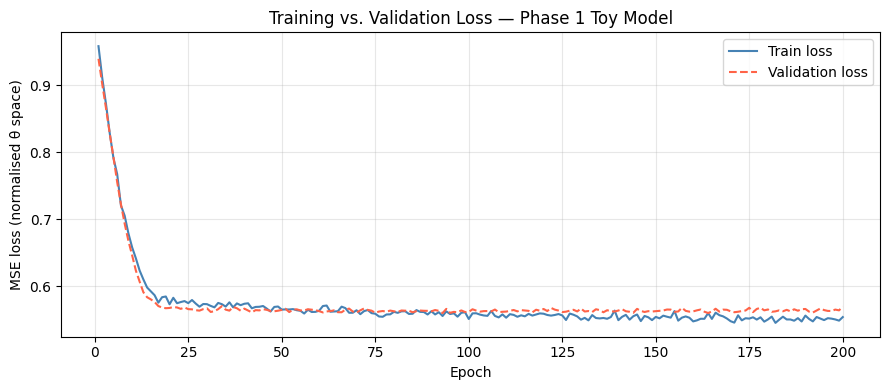

Loss curve saved to /content/drive/MyDrive/ns_eos_project/figures/loss_curve_phase1.png
Final train loss : 0.554065
Final val   loss : 0.569778


In [ ]:
epochs = range(1, NUM_EPOCHS + 1)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(epochs, train_losses, label='Train loss',      color='steelblue', linewidth=1.5)
ax.plot(epochs, val_losses,   label='Validation loss', color='tomato',    linewidth=1.5,
        linestyle='--')

ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss (normalised θ space)')
ax.set_title('Training vs. Validation Loss — Phase 1 Toy Model')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

loss_fig_path = f'{FIGURES}/loss_curve_phase1.png'
fig.savefig(loss_fig_path, dpi=150)
plt.show()
print(f'Loss curve saved to {loss_fig_path}')
print(f'Final train loss : {train_losses[-1]:.6f}')
print(f'Final val   loss : {val_losses[-1]:.6f}')

---
## Section 9: Evaluation

 generates **20 completely fresh test samples** (never seen during training
or validation) to assess how well the trained model recovers EOS parameters.

The scatter plots show **true vs. predicted** for each of the four parameters.
Points close to the red dashed diagonal mean accurate recovery.  For the
toy model we expect γ₀ and γ₁ to recover reasonably well (large coefficients
in the forward model) and γ₂, γ₃ to be noisier, which should improve with the
real TOV solver and 50 k training samples in Phase 2.

True EOS vs. Predicted EOS (first 5 test samples):
         true γ₀    pred γ₀     true γ₁    pred γ₁     true γ₂    pred γ₂     true γ₃    pred γ₃
------------------------------------------------------------------------------------------------
   0      1.1532     0.8851      0.0289     0.1542     -0.0797    -0.0210      0.0072    -0.0004
   1      0.8257     1.1052     -0.6496    -0.7123      0.1156    -0.0423      0.0094    -0.0013
   2      0.8339     0.7993     -0.0364    -0.0519     -0.5988     0.0017      0.0149    -0.0003
   3      1.1823     1.3173      0.5892     0.5172     -0.2958    -0.0493     -0.0016     0.0005
   4      0.5714     1.1952     -1.3054    -1.7445      0.5048    -0.0256     -0.0049    -0.0070


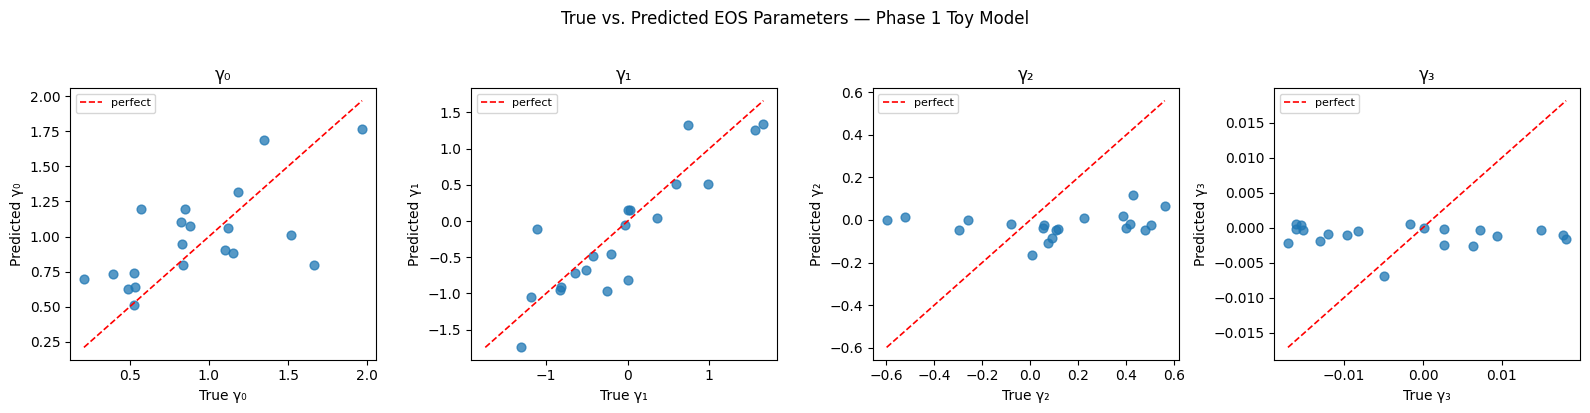

Evaluation scatter plot saved to /content/drive/MyDrive/ns_eos_project/figures/true_vs_predicted_phase1.png


In [ ]:
# ── Generate fresh test samples (unseen during training or validation) ─────────
N_TEST = 20
test_samples = [generate_toy_sample() for _ in range(N_TEST)]
test_dataset = EOSCatalogDataset(test_samples)
test_loader  = DataLoader(test_dataset, batch_size=N_TEST,
                           shuffle=False, collate_fn=collate_fn)

# ── Run inference ─────────────────────────────────────────────────────────────
model.eval()

with torch.no_grad():
    batch = next(iter(test_loader))
    batch = move_to_device(batch, device)

    theta_true = batch['theta'].cpu()                          # (20, 4)  true params
    pred_norm  = model(batch)                                  # (20, 4)  normalised
    theta_pred = denormalize_theta(pred_norm).cpu()            # (20, 4)  physical units

# ── Print comparison table for all four parameters ────────────────────────────
param_names = ['γ₀', 'γ₁', 'γ₂', 'γ₃']
header = f"{'':>4}" + "".join(f"  {'true '+p:>10} {'pred '+p:>10}" for p in param_names)
print('True EOS vs. Predicted EOS (first 5 test samples):')
print(header)
print('-' * len(header))
for i in range(5):
    row = f'{i:>4}'
    for j in range(4):
        row += f'  {theta_true[i, j]:>10.4f} {theta_pred[i, j]:>10.4f}'
    print(row)

# ── Scatter plots: true vs. predicted for each parameter ──────────────────────
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, (ax, name) in enumerate(zip(axes, param_names)):
    true_vals = theta_true[:, i].numpy()
    pred_vals = theta_pred[:, i].detach().numpy()

    ax.scatter(true_vals, pred_vals, alpha=0.75, s=40)

    # Perfect-prediction diagonal
    lo = min(true_vals.min(), pred_vals.min())
    hi = max(true_vals.max(), pred_vals.max())
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.2, label='perfect')

    ax.set_xlabel(f'True {name}')
    ax.set_ylabel(f'Predicted {name}')
    ax.set_title(name)
    ax.legend(fontsize=8)

fig.suptitle('True vs. Predicted EOS Parameters — Phase 1 Toy Model', y=1.02)
fig.tight_layout()

eval_fig_path = f'{FIGURES}/true_vs_predicted_phase1.png'
fig.savefig(eval_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Evaluation scatter plot saved to {eval_fig_path}')

---
## Section 10: Permutation Invariance Test

The architecture guarantees permutation invariance by construction (mean pooling
commutes with reordering).  This cell verifies that property empirically

**procedure:**
1. Take one catalog with ≥ 3 observations.
2. Run the model and record the output.
3. Shuffle the observation order 5 times and run the model again each time.
4. Compute the maximum absolute deviation from the original output.

Expected result: max deviation < 1e-5 (limited by floating-point precision,
not by any permutation sensitivity).

In [ ]:
# ── Find a sample with at least 3 observations ────────────────────────────────
perm_sample = None
for s in all_samples:
    if len(s['catalog']) >= 3:
        perm_sample = s
        break

assert perm_sample is not None, 'Could not find a sample with ≥ 3 observations.'

obs_types = [o['type'] for o in perm_sample['catalog']]
print(f'Test catalog has {len(perm_sample["catalog"])} observations: {obs_types}')
print()

def run_model_on_sample(sample: dict) -> torch.Tensor:
    """Wrap a single sample in a one-item batch and run the model."""
    dataset_item = EOSCatalogDataset([sample])
    loader       = DataLoader(dataset_item, batch_size=1, collate_fn=collate_fn)
    batch        = next(iter(loader))
    batch        = move_to_device(batch, device)
    with torch.no_grad():
        return model(batch).cpu()   # (1, 4)

# ── Baseline prediction with original catalog order ───────────────────────────
model.eval()
pred_original = run_model_on_sample(perm_sample)
print(f'Original prediction: {pred_original.numpy().round(6)}')
print()

# ── Shuffle the catalog 5 times and check deviation ───────────────────────────
N_SHUFFLES = 5
max_deviation = 0.0

for shuffle_idx in range(N_SHUFFLES):
    # Make a copy so we don't modify the original
    shuffled_catalog = perm_sample['catalog'].copy()
    random.shuffle(shuffled_catalog)

    shuffled_sample = {
        'theta_eos': perm_sample['theta_eos'],
        'catalog':   shuffled_catalog,
    }
    pred_shuffled = run_model_on_sample(shuffled_sample)

    deviation = (pred_shuffled - pred_original).abs().max().item()
    max_deviation = max(max_deviation, deviation)

    shuffled_types = [o['type'] for o in shuffled_catalog]
    print(f'Shuffle {shuffle_idx + 1}: order = {shuffled_types}')
    print(f'  prediction = {pred_shuffled.numpy().round(6)}')
    print(f'  max |deviation| from original = {deviation:.2e}')

# ── Summary ───────────────────────────────────────────────────────────────────
print()
print(f'Overall max |deviation| across {N_SHUFFLES} shuffles: {max_deviation:.2e}')

TOLERANCE = 1e-4
if max_deviation < TOLERANCE:
    print(f'✓ PASS  — deviation < {TOLERANCE:.0e} (permutation invariance confirmed)')
else:
    print(f'✗ FAIL  — deviation ≥ {TOLERANCE:.0e} (unexpected permutation sensitivity!)')

Test catalog has 5 observations: ['gw', 'gw', 'gw', 'nicer', 'pulsar']

Original prediction: [[-0.385753 -1.210238 -0.159438 -0.231802]]

Shuffle 1: order = ['gw', 'pulsar', 'gw', 'gw', 'nicer']
  prediction = [[-0.385753 -1.210238 -0.159438 -0.231802]]
  max |deviation| from original = 0.00e+00
Shuffle 2: order = ['pulsar', 'nicer', 'gw', 'gw', 'gw']
  prediction = [[-0.385753 -1.210238 -0.159438 -0.231802]]
  max |deviation| from original = 0.00e+00
Shuffle 3: order = ['gw', 'pulsar', 'gw', 'gw', 'nicer']
  prediction = [[-0.385753 -1.210238 -0.159438 -0.231802]]
  max |deviation| from original = 0.00e+00
Shuffle 4: order = ['pulsar', 'gw', 'nicer', 'gw', 'gw']
  prediction = [[-0.385753 -1.210238 -0.159438 -0.231802]]
  max |deviation| from original = 0.00e+00
Shuffle 5: order = ['gw', 'pulsar', 'gw', 'gw', 'nicer']
  prediction = [[-0.385753 -1.210238 -0.159438 -0.231802]]
  max |deviation| from original = 0.00e+00

Overall max |deviation| across 5 shuffles: 0.00e+00
✓ PASS  — devi